In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.cm as cm

In [ ]:
df = pd.read_csv('nFCC_vs_nTCC.csv')
df.dropna(inplace=True)
df.reset_index(drop=True, inplace=True)
df

,Model,nFCC,nTCC
0,STM_v1_0,979,1056
1,e_coli_core,8,8
2,iAB_RBC_283,41,47
3,iAF1260,853,950
4,iAF1260b,837,936
...,...,...,...
94,iYO844,620,705
95,iYS1720,1018,1136
96,iYS854,560,819
97,iZ_1308,1100,1219


In [ ]:
from scipy.stats import ttest_rel



In [ ]:
ttest_rel(df["nFCC"][df['nTCC']<2000], df["nTCC"][df['nTCC']<2000])

TtestResult(statistic=-16.09970317289433, pvalue=1.1529017277949347e-26, df=79)

{'whiskers': [<matplotlib.lines.Line2D at 0x786a71f05060>,
 'caps': [<matplotlib.lines.Line2D at 0x786a71f05480>,
 'boxes': [<matplotlib.lines.Line2D at 0x786a71f04dc0>,
 'medians': [<matplotlib.lines.Line2D at 0x786a71f059c0>,
 'fliers': [<matplotlib.lines.Line2D at 0x786a71f05c60>,
 'means': []}

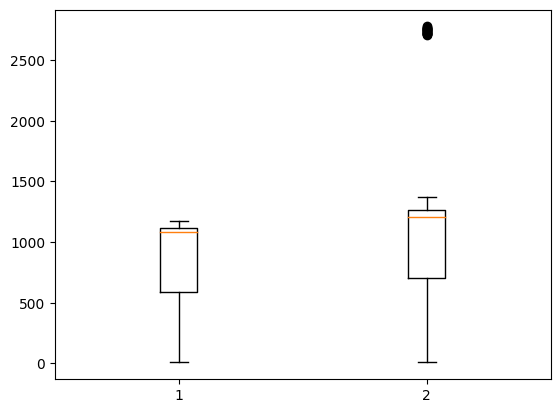

In [ ]:
plt.boxplot(df[['nFCC','nTCC']])

<ipython-input-17-2ba216b1b366>:8: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(ax.get_xticklabels(),fontsize=15)
<ipython-input-17-2ba216b1b366>:9: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_yticklabels(ax.get_yticklabels(),fontsize=15)


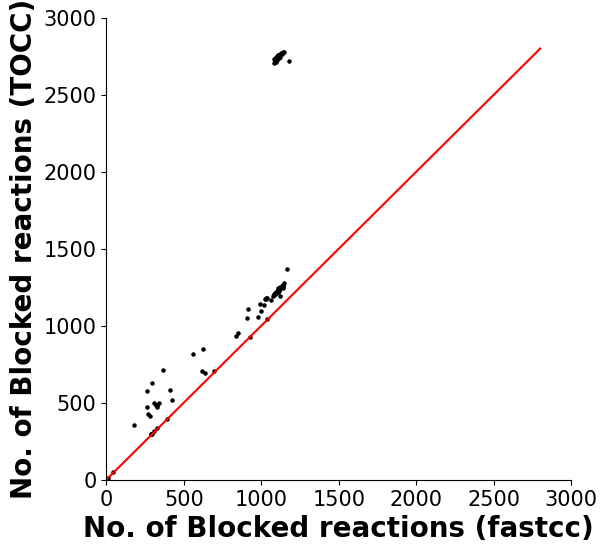

In [ ]:
fig,ax =plt.subplots(1,1,figsize=(6,6))
ax.scatter(df.nFCC,df.nTCC,s=5,c='k')
ax.plot([0,2800],[0,2800],c='r')
ax.set_xlim(0,3000)
ax.set_ylim(0,3000)
ax.set_xlabel("No. of Blocked reactions (fastcc)",fontweight='bold',fontsize=20)
ax.set_ylabel("No. of Blocked reactions (TOCC)",fontweight='bold',fontsize=20)
ax.set_xticklabels(ax.get_xticklabels(),fontsize=15)
ax.set_yticklabels(ax.get_yticklabels(),fontsize=15)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)


plt.savefig('TCC_vs_FCC.pdf',bbox_inches='tight')

In [ ]:
df = pd.read_csv('TICBefAft.csv')
df.dropna(inplace=True)
df.reset_index(drop=True, inplace=True)
df

,Model,nTICrxnsAft,nTICrxnsBef,nTICsBef,nTICsAft
0,STM_v1_0.mat,20,52,34,19
1,e_coli_core.mat,2,2,1,1
2,iAB_RBC_283.mat,3,9,5,1
3,iAF1260.mat,42,68,38,23
4,iAF1260b.mat,48,76,45,26
...,...,...,...,...,...
94,iYO844.mat,13,21,13,9
95,iYS1720.mat,74,114,71,49
96,iYS854.mat,37,46,44,36
97,iZ_1308.mat,83,110,76,56


<ipython-input-11-14ee5093701b>:6: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  ax.set_xlim(0,1300)
<ipython-input-11-14ee5093701b>:7: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax.set_ylim(0,1300)
<ipython-input-11-14ee5093701b>:10: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(ax.get_xticklabels(),fontsize=15)
<ipython-input-11-14ee5093701b>:11: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_yticklabels(ax.get_yticklabels(),fontsize=15)


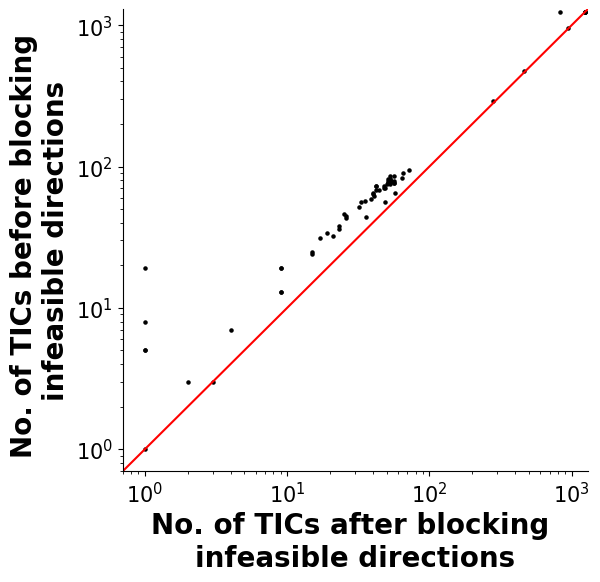

In [ ]:
fig,ax =plt.subplots(1,1,figsize=(6,6))
ax.scatter(df.nTICsAft,df.nTICsBef,s=5,c='k')
ax.plot([0,1300],[0,1300],c='r')
ax.set_yscale('log')
ax.set_xscale('log')
ax.set_xlim(0,1300)
ax.set_ylim(0,1300)
ax.set_ylabel("No. of TICs before blocking \ninfeasible directions",fontweight='bold',fontsize=20)
ax.set_xlabel("No. of TICs after blocking \ninfeasible directions",fontweight='bold',fontsize=20)
ax.set_xticklabels(ax.get_xticklabels(),fontsize=15)
ax.set_yticklabels(ax.get_yticklabels(),fontsize=15)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)


plt.savefig('TIC_bef_aft.pdf',bbox_inches='tight')

In [ ]:
np.sum(df.nTICsBef>=df.nTICsAft)